# Notebook 5 — FFT-Based Signal Processing

## Objective

Denoise every honest / theft consumption sequence with an FFT low-pass
filter **before** classification. FFT is used purely as a preprocessing
step here — the classifier in Notebook 6 still consumes time-domain
sequences, not frequency-domain features.

This notebook is intentionally thin: all logic lives in
`src/fft_pipeline/` (`dataset.py`, `filtering.py`, `visualize.py`). The
notebook only wires those modules together, exactly like Notebook 4.

### What this notebook does

1. Load `honest_sequences.npy`, `theft_sequences.npy` and
   `synthetic_theft_sequences.npy` (produced by Notebooks 3 and 4).
2. Merge `theft = theft_real + theft_synthetic`. Honest data is left
   untouched.
3. Apply an FFT low-pass filter to every sequence independently, then
   inverse-FFT back to the time domain (shape stays `(samples, 1033, 1)`).
4. Build binary labels (Honest = 0, Theft = 1), shuffle sequences and
   labels together, and save the result for Notebook 6.

### Why a low-pass filter, and why this cutoff

Electricity theft shows up as a **sustained, low-frequency** shift in
consumption behaviour (a suppressed baseline, missing usage on certain
days/weeks) — not as isolated single-day spikes. Meter noise and one-off
misreads, by contrast, are high-frequency and spread across many
spectral bins. A simple rectangular low-pass filter — keep the lowest
`cutoff_ratio` fraction of frequency bins, zero out the rest, inverse
FFT — removes that high-frequency noise while preserving weekly/seasonal
consumption trends. It is a single, explainable hyperparameter, which
matters for an academic report, and it avoids more complex DSP (IIR/FIR
filter design, wavelet decomposition) that would be harder to justify
and reproduce. See `src/fft_pipeline/filtering.py` for the full
rationale and implementation.

**This notebook does not modify Notebooks 1–4 or the TimeGAN
implementation.**

## Cell 1 — Imports & Reproducibility

All random state used in this notebook (currently just the fixed-seed
shuffle in Cell 8) is seeded from a single `SEED` constant so the
notebook's output is reproducible run-to-run.

In [1]:
import random
import sys
from pathlib import Path

import numpy as np

# Make src/ importable (notebook lives in notebooks/, src/ is a sibling of it).
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from fft_pipeline.dataset import (
    load_raw_sequences,
    merge_theft_sequences,
    build_labels,
    shuffle_dataset,
    save_dataset,
    save_fft_config,
)
from fft_pipeline.filtering import lowpass_filter_batch
from fft_pipeline.visualize import (
    apply_publication_style,
    plot_original_vs_filtered,
    plot_magnitude_spectra,
    plot_class_examples,
)

apply_publication_style()

print("NumPy:", np.__version__)
print("Project root:", PROJECT_ROOT)


NumPy: 2.4.6
Project root: /Users/manavagrawal/Documents/Smart-grid-theft-detection


## Cell 1b — Experiment Configuration

This notebook owns all experiment parameters for the FFT preprocessing
step — the `fft_pipeline` modules under `src/` are kept generic and take
these values as arguments rather than hardcoding them. This keeps every
run traceable to a single, visible constant in the notebook instead of a
default buried in library code.

`CUT_OFF_RATIO` is the fraction of the Nyquist frequency retained by the
low-pass filter (see Cell 4 markdown below for the full rationale behind
the value chosen).

In [2]:
# ---------------------------------------------------------
# Experiment configuration (owned by this notebook, not by src/fft_pipeline)
# ---------------------------------------------------------

SEED = 42
CUT_OFF_RATIO = 0.10  # fraction of Nyquist frequency retained by the low-pass filter

import random
random.seed(SEED)
np.random.seed(SEED)

print("=" * 50)
print(f"Random Seed      : {SEED}")
print(f"FFT Cutoff Ratio : {CUT_OFF_RATIO}")
print("=" * 50)


Random Seed      : 42
FFT Cutoff Ratio : 0.1


## Cell 2 — Load Notebook 3 / Notebook 4 Outputs

Loads `honest_sequences.npy`, `theft_sequences.npy` and
`synthetic_theft_sequences.npy` from `models/`. `load_raw_sequences`
validates that all three files exist and share the same sequence
length, raising a clear error otherwise (e.g. if Notebook 4 has not
been run yet).

In [3]:
MODELS_DIR = PROJECT_ROOT / "models"

try:
    raw = load_raw_sequences(
        honest_path=MODELS_DIR / "honest_sequences.npy",
        theft_path=MODELS_DIR / "theft_sequences.npy",
        synthetic_theft_path=MODELS_DIR / "synthetic_theft_sequences.npy",
    )
except FileNotFoundError as e:
    print("=" * 60)
    print("ERROR: Required input file(s) not found.")
    print("=" * 60)
    print(e)
    print()
    print("-> Please run Notebook 4 (TimeGAN synthesis) first and "
          "confirm it has saved its outputs into the models/ folder "
          "before running Notebook 5.")
    raise

print("Honest sequences          :", raw.honest.shape)
print("Theft sequences (real)    :", raw.theft_real.shape)
print("Theft sequences (synthetic):", raw.theft_synthetic.shape)

SEQ_LEN = raw.honest.shape[1]
print("Sequence length (T)       :", SEQ_LEN)


Honest sequences          : (38757, 1033, 1)
Theft sequences (real)    : (3615, 1033, 1)
Theft sequences (synthetic): (100, 1033, 1)
Sequence length (T)       : 1033


## Cell 3 — Merge Real + Synthetic Theft Sequences

`theft = theft_real + theft_synthetic`. Honest data remains unchanged,
as required — only the minority (theft) class is augmented with
TimeGAN samples.

In [4]:
honest = raw.honest
theft = merge_theft_sequences(raw.theft_real, raw.theft_synthetic)

print("Honest total :", honest.shape)
print("Theft total  :", theft.shape, "(real:", raw.theft_real.shape[0], "+ synthetic:", raw.theft_synthetic.shape[0], ")")
print()
print(f"Class balance -> Honest: {len(honest)} ({len(honest) / (len(honest) + len(theft)):.1%}), "
      f"Theft: {len(theft)} ({len(theft) / (len(honest) + len(theft)):.1%})")

Honest total : (38757, 1033, 1)
Theft total  : (3715, 1033, 1) (real: 3615 + synthetic: 100 )

Class balance -> Honest: 38757 (91.3%), Theft: 3715 (8.7%)


## Cell 4 — FFT Low-Pass Filtering

Every sequence is FFT-filtered **independently** with a hard low-pass
cutoff at `CUT_OFF_RATIO` of the Nyquist frequency, then inverse-FFT'd
back to the time domain. Output shape is guaranteed to match input shape
exactly — `(samples, 1033, 1)` — since `filtering.lowpass_filter_batch`
forces `n=T` on the inverse FFT.

### Why FFT is applied

Electricity consumption sequences are time-domain signals, so it is hard
to separate genuine consumption-behaviour trends from noise by looking
at the raw values alone. The Fast Fourier Transform re-expresses each
1033-day sequence as a sum of frequency components, which makes the
distinction explicit: slow, sustained behavioural shifts occupy the
low-frequency end of the spectrum, while meter noise and isolated
misreads are spread across the high-frequency end. Working in the
frequency domain is what makes it possible to remove the latter without
disturbing the former.

### Why an inverse FFT is performed

The GRU classifier in Notebook 6 is designed to consume **time-domain**
sequences, not frequency-domain features — this keeps the classifier
architecture simple and keeps FFT strictly as a denoising preprocessing
step rather than a feature-engineering step. After zeroing the
high-frequency bins, the inverse FFT (`irfft`) converts the truncated
spectrum back into a time-domain sequence of the original length. The
result is a smoothed version of the original signal with the same shape
and units, so it can be fed into the GRU exactly like the raw sequences
were.

### Why a low-pass filter is used

Theft manifests as a **sustained, low-frequency** shift in consumption
behaviour (e.g. an artificially suppressed daily baseline, or missing
usage across whole weeks) rather than as brief single-day spikes. A
low-pass filter keeps that low-frequency behavioural signal intact while
discarding the high-frequency energy associated with meter noise and
one-off misreads — i.e. it improves the signal-to-noise ratio of exactly
the pattern the classifier needs to learn. A rectangular cutoff (keep
the lowest `CUT_OFF_RATIO` fraction of bins, zero the rest) is used
instead of a Butterworth/Chebyshev/windowed filter because it is fully
explainable in one sentence, has a single interpretable hyperparameter,
and is standard practice for this kind of academic denoising step. See
`src/fft_pipeline/filtering.py` for the full implementation-level
rationale, including the accepted trade-off (mild Gibbs-phenomenon
ringing at sharp edges).

### Why 0.10 was selected as the baseline cutoff

For a 1033-day sequence, keeping the lowest 10% of frequency bins
retains cycles with a period of roughly 20 days or longer — i.e. weekly,
bi-weekly and monthly consumption patterns, which is the timescale at
which theft-related behavioural shifts are expected to appear. It
suppresses faster fluctuations attributable to meter noise or isolated
misreads while leaving enough spectral content that the filtered signal
still visibly resembles genuine consumption behaviour (see the
before/after plots in Cells 5–7). 0.10 is used as the baseline value for
this pipeline; because it is now a notebook-level constant
(`CUT_OFF_RATIO`, Cell 1b) rather than a hardcoded library default, it
can be revisited and re-justified (e.g. via an ablation study) without
touching `src/fft_pipeline/filtering.py`.

In [5]:
print(f"Low-pass cutoff ratio: {CUT_OFF_RATIO} "
      f"(keeping the lowest {CUT_OFF_RATIO:.0%} of frequency bins, i.e. cycles "
      f"of period >= ~{1 / CUT_OFF_RATIO:.0f} days are preserved)")

honest_filtered = lowpass_filter_batch(honest, cutoff_ratio=CUT_OFF_RATIO)
theft_filtered = lowpass_filter_batch(theft, cutoff_ratio=CUT_OFF_RATIO)

print("Honest filtered shape:", honest_filtered.shape)
print("Theft filtered shape :", theft_filtered.shape)

assert honest_filtered.shape == honest.shape
assert theft_filtered.shape == theft.shape
print("Shape check passed: filtering preserves (samples, 1033, 1).")

# Save the FFT experiment configuration for reproducibility (Notebook 7 / report).
RESULTS_DIR = PROJECT_ROOT / "results"
fft_config_path = save_fft_config(CUT_OFF_RATIO, RESULTS_DIR)
print("Saved FFT config    :", fft_config_path)


Low-pass cutoff ratio: 0.1 (keeping the lowest 10% of frequency bins, i.e. cycles of period >= ~10 days are preserved)
Honest filtered shape: (38757, 1033, 1)
Theft filtered shape : (3715, 1033, 1)
Shape check passed: filtering preserves (samples, 1033, 1).
Saved FFT config    : /Users/manavagrawal/Documents/Smart-grid-theft-detection/results/fft_config.json


## Cell 5 — Visualization: Original vs. Filtered Signal

One honest and one theft example, before and after filtering, so the
smoothing effect of the low-pass filter is visible directly in the
time domain.

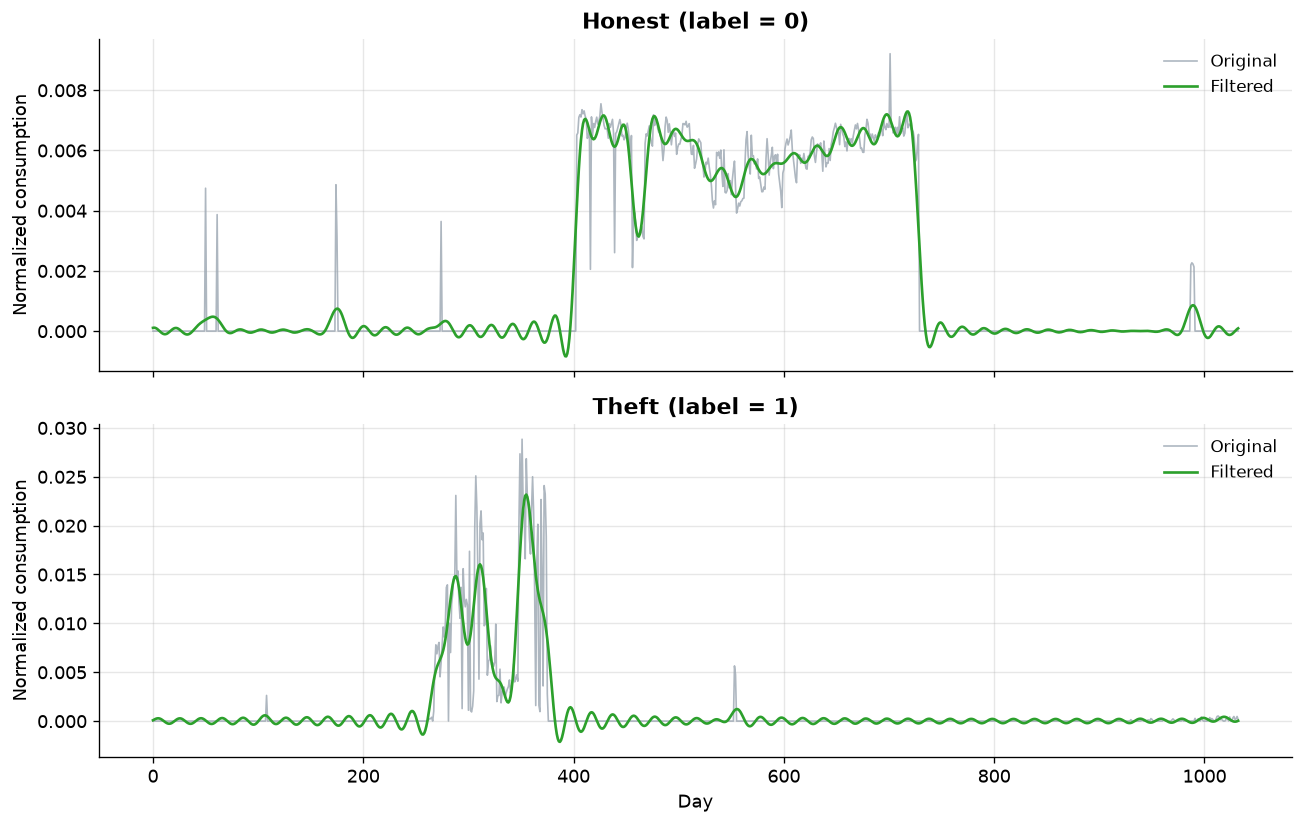

In [6]:
plot_class_examples(
    honest_original=honest[0],
    honest_filtered=honest_filtered[0],
    theft_original=theft[0],
    theft_filtered=theft_filtered[0],
)

## Cell 6 — Visualization: FFT Magnitude Spectrum (Before vs. After)

Confirms visually that the filter zeroes out the high-frequency tail
of the spectrum while leaving the low-frequency content (left of the
dashed cutoff line) untouched.

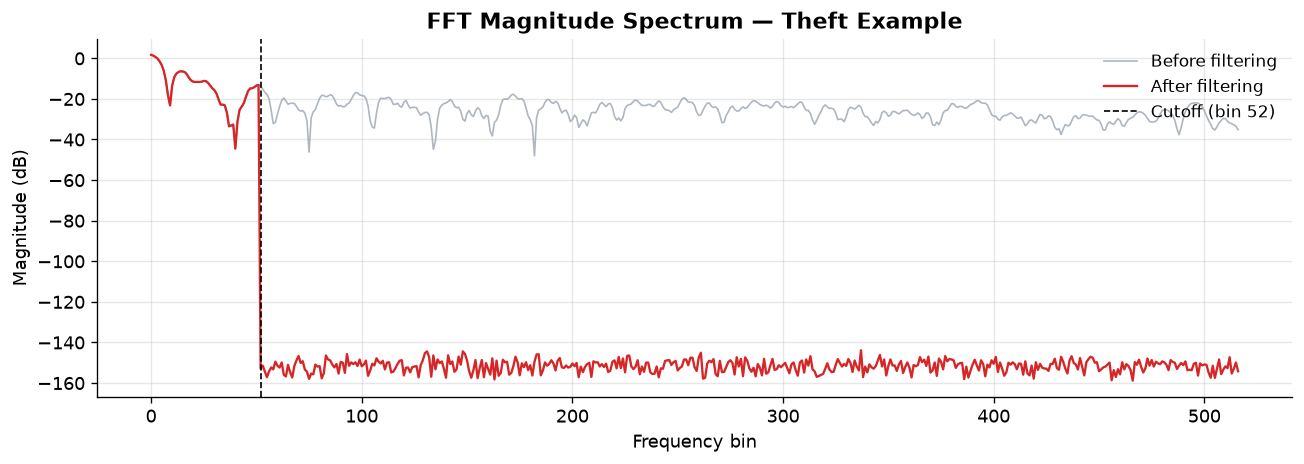

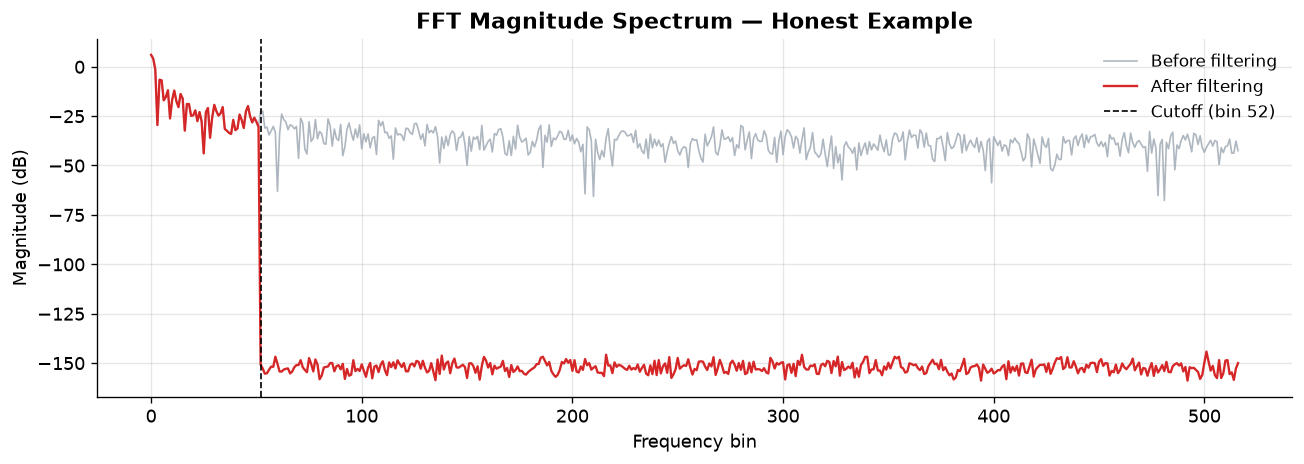

In [7]:
plot_magnitude_spectra(
    original=theft[0],
    filtered=theft_filtered[0],
    cutoff_ratio=CUT_OFF_RATIO,
    title="FFT Magnitude Spectrum — Theft Example",
)

plot_magnitude_spectra(
    original=honest[0],
    filtered=honest_filtered[0],
    cutoff_ratio=CUT_OFF_RATIO,
    title="FFT Magnitude Spectrum — Honest Example",
)

## Cell 7 — Additional Original vs. Filtered Examples

A couple more randomly sampled sequences from each class, for a
broader visual sanity check beyond the single example above.

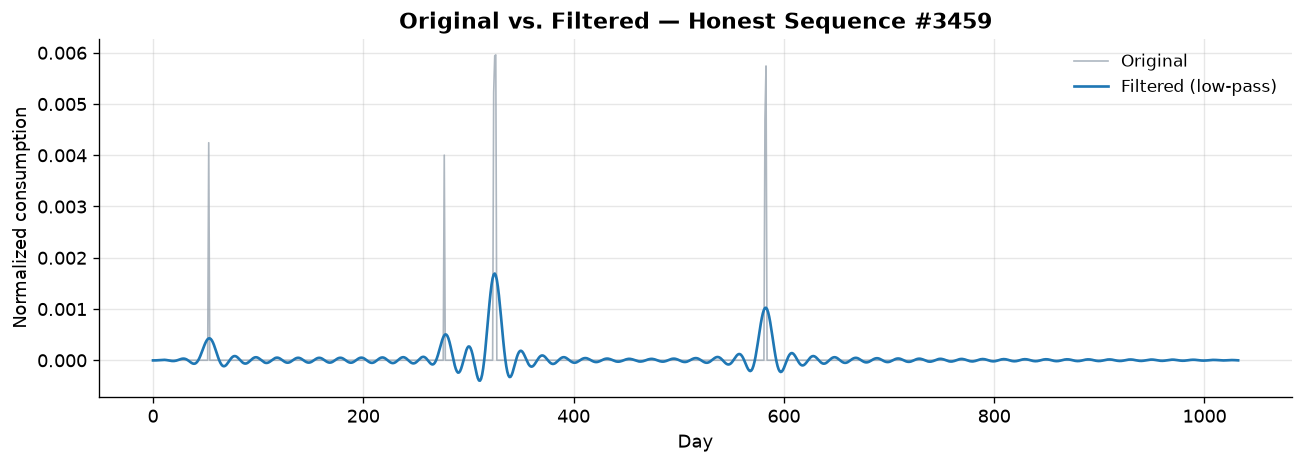

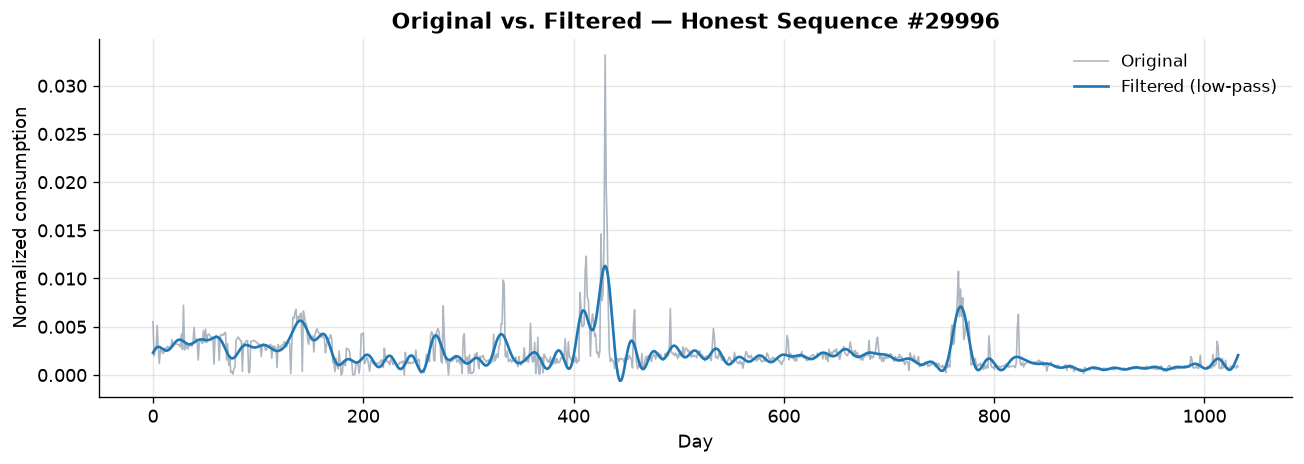

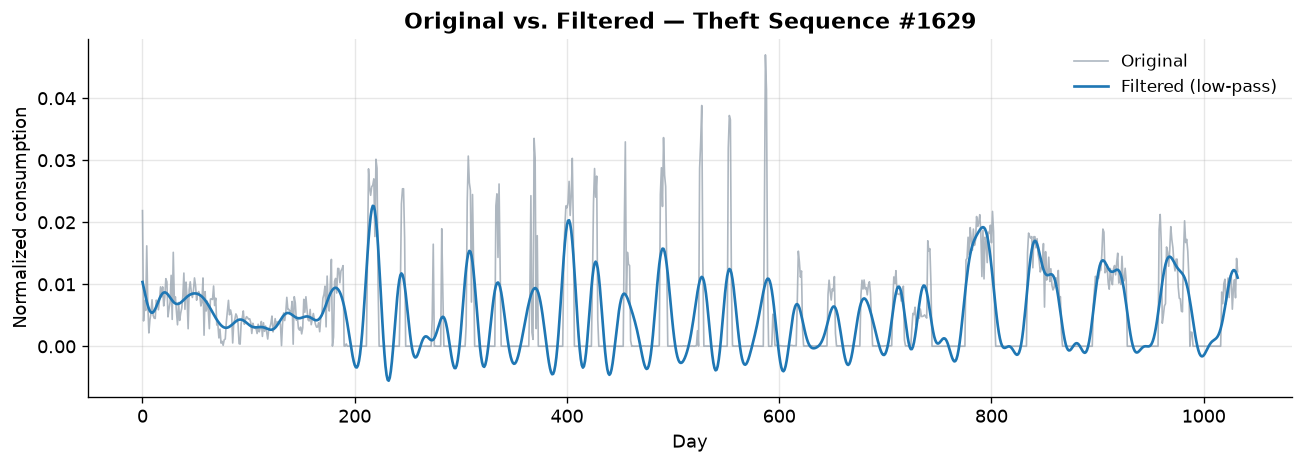

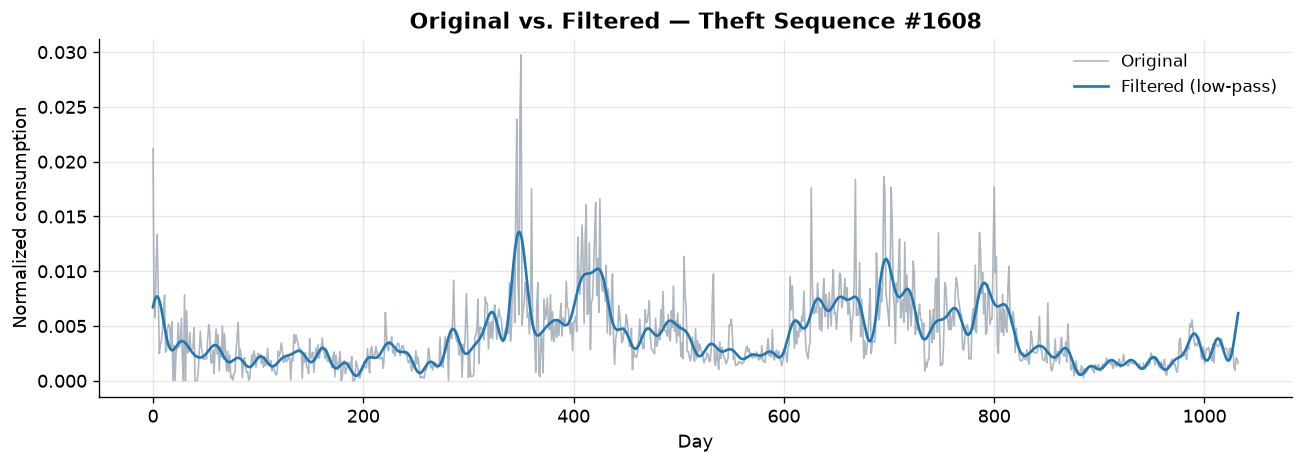

In [8]:
rng = np.random.default_rng(SEED)

for idx in rng.choice(len(honest), size=2, replace=False):
    plot_original_vs_filtered(
        honest[idx], honest_filtered[idx],
        title=f"Original vs. Filtered — Honest Sequence #{idx}",
    )

for idx in rng.choice(len(theft), size=2, replace=False):
    plot_original_vs_filtered(
        theft[idx], theft_filtered[idx],
        title=f"Original vs. Filtered — Theft Sequence #{idx}",
    )

## Cell 8 — Labels, Merge Classes, Shuffle

Labels: Honest = 0, Theft = 1. Sequences and labels are shuffled
together using a single fixed-seed permutation so the pairing stays
correct.

In [9]:
X = np.concatenate([honest_filtered, theft_filtered], axis=0)
y = build_labels(honest_filtered, theft_filtered)

print("Combined X shape:", X.shape)
print("Combined y shape:", y.shape)
print("Label counts -> Honest (0):", int((y == 0).sum()), "| Theft (1):", int((y == 1).sum()))

X, y = shuffle_dataset(X, y, seed=SEED)
print("Shuffled. First 10 labels:", y[:10])

Combined X shape: (42472, 1033, 1)
Combined y shape: (42472,)
Label counts -> Honest (0): 38757 | Theft (1): 3715
Shuffled. First 10 labels: [0 0 0 0 0 0 0 0 0 0]


## Cell 9 — Save `train_sequences_fft.npy` and `train_labels.npy`

These are the only two files Notebook 6 reads — it performs
classification only and does not regenerate FFT, TimeGAN, or labels.

In [10]:
sequences_path, labels_path = save_dataset(X, y, MODELS_DIR)

print("=" * 50)
print("Notebook 05 Completed")
print("=" * 50)
print("Sequences shape :", X.shape)
print("Labels shape    :", y.shape)
print("Saved sequences :", sequences_path)
print("Saved labels    :", labels_path)
print("FFT cutoff ratio:", CUT_OFF_RATIO)
print("Saved FFT config:", fft_config_path)
print("=" * 50)


Notebook 05 Completed
Sequences shape : (42472, 1033, 1)
Labels shape    : (42472,)
Saved sequences : /Users/manavagrawal/Documents/Smart-grid-theft-detection/models/train_sequences_fft.npy
Saved labels    : /Users/manavagrawal/Documents/Smart-grid-theft-detection/models/train_labels.npy
FFT cutoff ratio: 0.1
Saved FFT config: /Users/manavagrawal/Documents/Smart-grid-theft-detection/results/fft_config.json
